   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 9.3 MB/s eta 0:00:00


Saving 1.rst to 1.rst
 Uploaded: 1.rst

 Reading 1.rst ...
 RST loaded | 1942 nodes, 579 elements
 20 load steps found
 Loaded NSL
 Loaded ENS
 Loaded EEL
 Loaded EPT
 Keys: ['NSL', 'ENS', 'EEL', 'EPT']
 Clean data: 682 samples
 Training on: cpu
Epoch   1/50 | Loss=0.9816 | RMSE=1.5604 | MAE=1.3977
Epoch   5/50 | Loss=0.5568 | RMSE=0.7790 | MAE=0.6223
Epoch  10/50 | Loss=0.4650 | RMSE=0.6896 | MAE=0.3788
Epoch  15/50 | Loss=0.4467 | RMSE=0.6518 | MAE=0.4232
Epoch  20/50 | Loss=0.4129 | RMSE=0.6165 | MAE=0.3752
Epoch  25/50 | Loss=0.3978 | RMSE=0.6013 | MAE=0.3765
Epoch  30/50 | Loss=0.3804 | RMSE=0.5820 | MAE=0.3413
Epoch  35/50 | Loss=0.3658 | RMSE=0.5574 | MAE=0.3281
Epoch  40/50 | Loss=0.3508 | RMSE=0.5402 | MAE=0.3148
Epoch  45/50 | Loss=0.3356 | RMSE=0.5352 | MAE=0.3159
Epoch  50/50 | Loss=0.3146 | RMSE=0.5125 | MAE=0.3003
 Final Validation | RMSE=0.512464, MAE=0.300345
 Saved model + scalers to /content/surrogate_output/


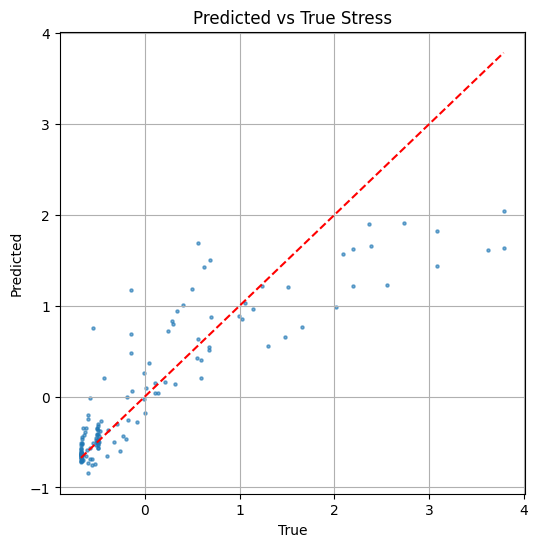

In [1]:
!pip install numpy scipy scikit-learn torch tqdm ansys-mapdl-reader matplotlib --quiet

from google.colab import files
uploaded = files.upload()
rst_path = list(uploaded.keys())[0]
print(f" Uploaded: {rst_path}")


import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from tqdm import tqdm

try:
    from ansys.mapdl.reader import read_binary
except Exception as e:
    raise ImportError("Please install `ansys-mapdl-reader` to read .rst files.") from e


def load_rst(path):
    """Extract node coordinates and result data (displacement, stress, strain, temperature)."""
    rst = read_binary(path)
    print(f" RST loaded | {rst.mesh.n_node} nodes, {rst.mesh.n_elem} elements")

    nodes = rst.mesh.nodes
    nsets = rst.nsets
    print(f" {nsets} load steps found")

    results = {}

    def safe_load(name, func):
        try:
            nnum, data = func(0)
            results[name] = data[np.newaxis, ...]
            print(f" Loaded {name}")
        except Exception as e:
            print(f" Skipped {name}: {e}")

    safe_load("NSL", rst.nodal_solution)
    safe_load("ENS", rst.nodal_stress)
    safe_load("EEL", rst.nodal_elastic_strain)
    safe_load("EPT", rst.nodal_temperature)

    return {"nodes": np.asarray(nodes), "results": results}


def compute_von_mises(stress):
    """Compute Von Mises stress from tensor components."""
    sxx, syy, szz, sxy, syz, szx = stress.T
    return np.sqrt(0.5 * ((sxx - syy)**2 + (syy - szz)**2 + (szz - sxx)**2)
                   + 3 * (sxy**2 + syz**2 + szx**2))


class NodeDataset(Dataset):
    """Converts ANSYS simulation data into ML-ready (X, y) samples."""
    def __init__(self, nodes, results, target="ENS", normalize=True):
        self.nodes = nodes
        self.results = results
        self.target = target
        input_keys = [k for k in ["NSL", "EPT"] if k in results]

        X_all, y_all = [], []
        for step in range(results[target].shape[0]):
            target_data = results[target][step]
            y = compute_von_mises(target_data) if target_data.shape[1] >= 6 else np.linalg.norm(target_data, axis=1)

            features = [nodes]
            for key in input_keys:
                arr = results[key][step]
                features.append(np.linalg.norm(arr, axis=1).reshape(-1, 1) if arr.ndim > 1 else arr.reshape(-1, 1))
            X_all.append(np.concatenate(features, axis=1))
            y_all.append(y.reshape(-1, 1))

        X_all, y_all = np.vstack(X_all), np.vstack(y_all)

        mask = np.isfinite(X_all).all(axis=1) & np.isfinite(y_all).all(axis=1)
        X_all, y_all = X_all[mask], y_all[mask]
        print(f" Clean data: {len(X_all)} samples")

        self.X_mean, self.X_std = X_all.mean(0), X_all.std(0) + 1e-8
        self.y_mean, self.y_std = y_all.mean(0), y_all.std(0) + 1e-8

        self.X = (X_all - self.X_mean) / self.X_std if normalize else X_all
        self.y = (y_all - self.y_mean) / self.y_std if normalize else y_all

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return torch.tensor(self.X[i]).float(), torch.tensor(self.y[i]).float()


class MLP(nn.Module):
    def __init__(self, in_dim, out_dim=1, hidden=[512, 256, 128]):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.LayerNorm(h)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)


def evaluate(model, loader, device='cpu'):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            yps.append(model(X).cpu().numpy())
            ys.append(y.cpu().numpy())
    ys, yps = np.vstack(ys), np.vstack(yps)
    return np.sqrt(mean_squared_error(ys, yps)), mean_absolute_error(ys, yps), ys, yps


def train(model, train_loader, val_loader, epochs=50, lr=1e-3, device='cpu'):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.to(device)

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            loss = loss_fn(model(X), y)
            opt.zero_grad(); loss.backward(); opt.step()
            running_loss += loss.item() * len(X)
        running_loss /= len(train_loader.dataset)

        if epoch % 5 == 0 or epoch == 1:
            rmse, mae, _, _ = evaluate(model, val_loader, device)
            print(f"Epoch {epoch:3d}/{epochs} | Loss={running_loss:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
    return model


print(f"\n Reading {rst_path} ...")
data = load_rst(rst_path)
nodes, results = data['nodes'], data['results']
print(f" Keys: {list(results.keys())}")

target_key = "ENS"

dataset = NodeDataset(nodes, results, target=target_key)
n = len(dataset)
idx = np.arange(n)
np.random.shuffle(idx)
split = int(0.8 * n)
train_loader = DataLoader(Subset(dataset, idx[:split]), batch_size=2048, shuffle=True)
val_loader = DataLoader(Subset(dataset, idx[split:]), batch_size=2048)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f" Training on: {device}")

model = MLP(in_dim=dataset.X.shape[1])
model = train(model, train_loader, val_loader, epochs=50, lr=1e-3, device=device)

rmse, mae, y_true, y_pred = evaluate(model, val_loader, device)
print(f" Final Validation | RMSE={rmse:.6f}, MAE={mae:.6f}")

os.makedirs("/content/surrogate_output", exist_ok=True)
torch.save(model.state_dict(), "/content/surrogate_output/mlp_surrogate.pth")
np.savez("/content/surrogate_output/scalers.npz",
         X_mean=dataset.X_mean, X_std=dataset.X_std,
         y_mean=dataset.y_mean, y_std=dataset.y_std)
print(" Saved model + scalers to /content/surrogate_output/")

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=5, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("True"), plt.ylabel("Predicted"), plt.title("Predicted vs True Stress")
plt.grid(); plt.show()
